StateGraph is the core blueprint used to build stateful, multi-actor applications like AI agents and workflows. It defines a cyclical graph where nodes (functions) and edges (control logic) communicate by reading and writing to a single, shared State object

Core Components of a StateGraph
1) State: The central data structure (usually a TypedDict, Pydantic model, or dataclass) that acts as the memory for the entire execution. It holds inputs, outputs, conversation history, or any data your agent tracks.

2) Nodes: Python or TypeScript functions that execute the logic of your application (e.g., calling an LLM, searching a database). They receive the current state, perform a computation, and return the updated values to the state.

3) Edges: Determine which node executes next based on the current state. They can be simple, fixed transitions or conditional branches.

4) Reducers: Special functions you assign to state keys that dictate how multiple updates from different nodes should be combined (e.g., overwriting a string or appending new messages to a list).

### Building a basic Chatbot with LangGraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages #reducer




In [2]:
class State(TypedDict):         # Messages have the type "list". The `add_messages` function
                                # in the annotation defines how this state key should be updated
                                # (in this case, it appends messages to the list, rather than overwriting them)
   # Annotated is the Python mechanism used to attach a reducer function to a specific key in the LangGraph state schema.
  
  messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)


In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E137DC4790>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E137E6FAD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# thorugh init_chat_model
llm=init_chat_model("llama-3.3-70b-versatile", model_provider="groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E137E7E8D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E137E7F4D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
#Node Functionality
def chatbot(state: State):
    return {"messages" : [llm.invoke(state["messages"])]}

In [9]:
graph_builder=StateGraph(State)
graph_builder.add_node("llm_chatbot", chatbot) #adding node
graph_builder.add_edge(START, "llm_chatbot") #adding edges
graph_builder.add_edge("llm_chatbot", END)
#compiling the graph
graph=graph_builder.compile()



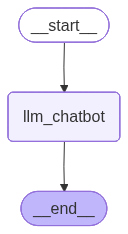

In [10]:
## Visualizing the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response=graph.invoke({"messages" : "Hi"})

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi,How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?


### Chatbot with Tool through Langraph

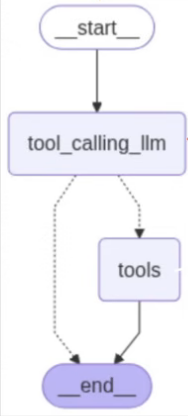

In [14]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("What is Langgraph")

{'query': 'What is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to 

In [30]:
## Custom Function
def multiply(a:int, b:int)->int:
     """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
     return a*b


In [16]:
tools=[tool,multiply]

In [17]:
llm_with_tool=llm.bind_tools(tools)

In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E137E7E8D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E137E7F4D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search e

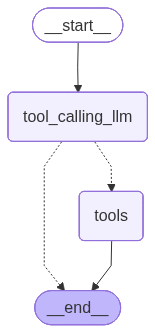

In [20]:
## Creating Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
#Creating graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm )
builder.add_node("tools",ToolNode(tools))

#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(  #Two edges coming from node
    "tool_calling_llm",
    #if latest message(result) from assistant is tool call then tools_conidition routes to tool
    #if not then tools_condition routes to END
    tools_condition 
)
builder.add_edge("tools", END)

##Compiling the graph
graph=builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response=graph.invoke({"messages"  : "What is recent developments in AI?"})

In [23]:
response['messages'][-1].content

'{"query": "recent developments in AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://spectrum.ieee.org/topic/artificial-intelligence", "title": "AI News & Articles - Artificial Intelligence Updates - IEEE Spectrum", "content": "## Journal Watch\\n\\n## Visual Language Models Train Robots to Read Human Emotions\\n\\nIllustration of a shoulders-up human silhouette with facial attributes vaguely outlined by recognition points.\\n\\n## Deepfake Detection Dataset Aims to Keep Up With Generative AI\\n\\nAbstract photo collage of flawed imagery, such as a human hand with two thumbs.\\n\\n## Optical Fiber Networks Can Keep Rail Networks Safe\\n\\nIllustration of a fiber optic cable installed across the front of a railroad sound barrier wall.\\n\\n## HIPPO Turns One Master Password Into Many Without Storing Any\\n\\nPersonified dots sneaking out of a hidden password field on a login page.\\n\\n## Mars Rover Sets New Autonomous Driving Record\\n\\nA sel

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent developments in AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (r0j92rcxt)
 Call ID: r0j92rcxt
  Args:
    query: recent developments in AI
    search_depth: advanced
    time_range: month
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent developments in AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://spectrum.ieee.org/topic/artificial-intelligence", "title": "AI News & Articles - Artificial Intelligence Updates - IEEE Spectrum", "content": "## Journal Watch\n\n## Visual Language Models Train Robots to Read Human Emotions\n\nIllustration of a shoulders-up human silhouette with facial attributes vaguely outlined by recognition points.\n\n## Deepfake Detection Dataset Aims to Keep Up With Generat

In [26]:
response=graph.invoke({"messages"  : "When Summer festival ended in Shimla, Himachal Pradesh, India?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

When Summer festival ended in Shimla, Himachal Pradesh, India?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (p35558dgb)
 Call ID: p35558dgb
  Args:
    end_date: None
    exclude_domains: None
    include_domains: None
    include_images: False
    query: Summer festival end date Shimla Himachal Pradesh India
    search_depth: basic
    start_date: None
    time_range: None
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "Summer festival end date Shimla Himachal Pradesh India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.indianholiday.com/himachal-pradesh/fairs-and-festivals/shimla-summer-festival.html", "title": "Summer Festival Shimla - Dates, Location & How to Reach", "content": "Summer Festival Shimla · Dates 

### Agentic AI Archietcture (ReAct Arch.)
1) Reason
The  llm thinks about the problem.It makes a smart plan.It decides what to do next.
2) Act: The llm takes an action.It uses an external tool.It looks up information or runs code.
3) Observe:
The LLM looks at the results.It sees what changed.It learns from the tool's response


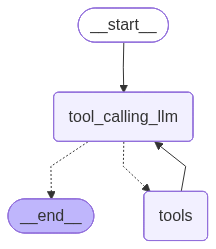

In [31]:
## Creating Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
#Creating graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm )
builder.add_node("tools",ToolNode(tools))

#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(  #Two edges coming from node
    "tool_calling_llm",
    #if latest message(result) from assistant is tool call then tools_conidition routes to tool
    #if not then tools_condition routes to END
    tools_condition 
)
builder.add_edge("tools", "tool_calling_llm")

##Compiling the graph
graph=builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
response=graph.invoke({"messages"  : "What is history of Shimla and then after this you have to dive 4 by 2?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is history of Shimla and then after this you have to dive 4 by 2?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jz6vq2sez)
 Call ID: jz6vq2sez
  Args:
    query: history of Shimla
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "history of Shimla", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://hpshimla.nic.in/history", "title": "History of Shimla Town | Shimla District, Government of Himachal Pradesh | India", "content": "History of Shimla goes back to the period of Anglo-Gurkha war in the beginning of 19th century. In 1804 the Gurkhas , who had suffered a severe defeat at the hands of the Sikhs at the battle of Kangra, a hill fortress about sixty miles from Shimla, where according to som

## Adding Memory in Angentic Graph

In [37]:
# Example of why its required
response=graph.invoke({"messages"  : "Hi , I live in Shimla"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi , I live in Shimla
================================== Ai Message ==================================

Shimla is a beautiful city in the Himalayan foothills of India. How can I assist you today? Are you looking for information about Shimla or something else?


In [38]:
# Example of why its required
response=graph.invoke({"messages"  : "Where do I live?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Where do I live?
================================== Ai Message ==================================

I don't have that information.


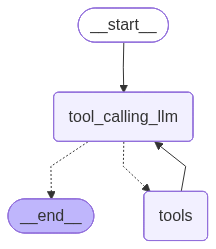

In [43]:
## Creating Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

#Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
#Creating graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm )
builder.add_node("tools",ToolNode(tools))

#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(  #Two edges coming from node
    "tool_calling_llm",
    #if latest message(result) from assistant is tool call then tools_conidition routes to tool
    #if not then tools_condition routes to END
    tools_condition 
)
builder.add_edge("tools", "tool_calling_llm")

##Compiling the graph
graph=builder.compile(checkpointer=memory)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
config={"configurable": {"thread_id":"1"}} 
response=graph.invoke({"messages":"Hi, I live in Shimla"}, config=config)
response

{'messages': [HumanMessage(content='Hi, I live in Shimla', additional_kwargs={}, response_metadata={}, id='e8f4cf53-94f6-4581-aeef-b9a5285a695f'),
  AIMessage(content='Shimla is a beautiful hill station in the Himalayas, known for its stunning scenery, pleasant weather, and rich history. What would you like to know or discuss about Shimla?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 1752, 'total_tokens': 1791, 'completion_time': 0.120489108, 'completion_tokens_details': None, 'prompt_time': 0.094031633, 'prompt_tokens_details': None, 'queue_time': 0.054260647, 'total_time': 0.214520741}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee467-43ee-79c2-8bd9-cd3473d6e6d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 39, 'total_tokens': 179

In [ ]:
## Testing after adding memory saver
response['messages'][-1].content

'Shimla is a beautiful hill station in the Himalayas, known for its stunning scenery, pleasant weather, and rich history. What would you like to know or discuss about Shimla?'

In [47]:
response=graph.invoke({"messages":"Hi, Where do I live"}, config=config)
print(response['messages'][-1].content)

You live in Shimla.


### Streaming in LangGraph

In [48]:
# Initializing Memory Saver
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()


In [49]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

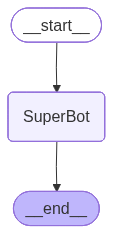

In [50]:
# Creating Simple Graph
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [51]:
## Invoking

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,I live in Shimla and I like Cricket!"},config)

{'messages': [HumanMessage(content='Hi,I live in Shimla and I like Cricket!', additional_kwargs={}, response_metadata={}, id='71fec022-1a06-4450-9da7-1b9e5cc73d37'),
  AIMessage(content='Shimla is a beautiful hill station in the Himalayas. The scenic views and pleasant weather must make it a lovely place to live. \n\nCricket is an extremely popular sport in India, and Shimla has its own cricket team, the Himachal Pradesh cricket team. They have a home ground, the Himachal Pradesh Cricket Association Stadium, which has hosted several domestic and international matches.\n\nAre you a fan of the Indian cricket team or do you support a specific team in the Indian Premier League (IPL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 46, 'total_tokens': 152, 'completion_time': 0.316143622, 'completion_tokens_details': None, 'prompt_time': 0.002184661, 'prompt_tokens_details': None, 'queue_time': 0.054418369, 'total_time': 0.318328283}, 'mo

Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [ ]:
# Using updates, specifically output gets updated/displayed
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi, I live in Shimla and I like Cricket!"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Shimla is a beautiful city in the Himalayas. The scenic views and cool climate must make it a lovely place to live. \n\nCricket is an extremely popular sport in India, and Shimla has its own cricket enthusiasts. The city has hosted several cricket matches, including some high-profile ones, at the Himachal Pradesh Cricket Association Stadium.\n\nAre you a fan of the Indian cricket team or do you support a specific IPL team?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 47, 'total_tokens': 137, 'completion_time': 0.345760582, 'completion_tokens_details': None, 'prompt_time': 0.00845305, 'prompt_tokens_details': None, 'queue_time': 0.0545294, 'total_time': 0.354213632}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee472-b62f-78f0-a734-9454d757

In [ ]:
# Using values, all info gets updated/dispalayed
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi, I live in Shimla and I like Cricket!"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, I live in Shimla and I like Cricket!', additional_kwargs={}, response_metadata={}, id='cc1b966c-1667-46c3-90d3-54b7348ee301'), AIMessage(content='Shimla is a beautiful city in the Himalayas. The scenic views and cool climate must make it a lovely place to live. \n\nCricket is an extremely popular sport in India, and Shimla has its own cricket enthusiasts. The city has hosted several cricket matches, including some high-profile ones, at the Himachal Pradesh Cricket Association Stadium.\n\nAre you a fan of the Indian cricket team or do you support a specific IPL team?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 47, 'total_tokens': 137, 'completion_time': 0.345760582, 'completion_tokens_details': None, 'prompt_time': 0.00845305, 'prompt_tokens_details': None, 'queue_time': 0.0545294, 'total_time': 0.354213632}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'se

In [54]:
# Using updates, specifically output gets updated/displayed
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi, I live in Shimla and I like Cricket!"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Shimla is a beautiful hill station in the Himalayas. The scenic views and pleasant weather must make it a great place to live. \n\nCricket is an extremely popular sport in India, and it's wonderful that you enjoy it. Who's your favorite cricketer, and do you have a favorite team? Have you ever watched a live match at the Himachal Pradesh Cricket Association Stadium in Dharamshala, which is not too far from Shimla?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 47, 'total_tokens': 143, 'completion_time': 0.388585785, 'completion_tokens_details': None, 'prompt_time': 0.012435718, 'prompt_tokens_details': None, 'queue_time': 0.050069042, 'total_time': 0.401021503}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee475-3379-7860-b881-cd7840c26f9d-0

In [55]:
for chunk in graph_builder.stream({'messages':"I also like Watching Avengers"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, I live in Shimla and I like Cricket!', additional_kwargs={}, response_metadata={}, id='051580ed-a73e-4a49-a288-f32de72e3419'), AIMessage(content="Shimla is a beautiful hill station in the Himalayas. The scenic views and pleasant weather must make it a great place to live. \n\nCricket is an extremely popular sport in India, and it's wonderful that you enjoy it. Who's your favorite cricketer, and do you have a favorite team? Have you ever watched a live match at the Himachal Pradesh Cricket Association Stadium in Dharamshala, which is not too far from Shimla?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 47, 'total_tokens': 143, 'completion_time': 0.388585785, 'completion_tokens_details': None, 'prompt_time': 0.012435718, 'prompt_tokens_details': None, 'queue_time': 0.050069042, 'total_time': 0.401021503}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_

In [ ]:
config = {"configurable": {"thread_id": "5"}} 
## For getting more detailed information like in debugging tasks 

async for event in graph_builder.astream_events({"messages":["Hi I live in Shimla and I like Cricket!"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi I live in Shimla and I like Cricket!']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ee478-8e0c-7dc1-85bc-f27581aa218d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi I live in Shimla and I like Cricket!', additional_kwargs={}, response_metadata={}, id='39c53892-24f6-499d-8656-2371de5cb5b7')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ee478-8e0e-7430-ad81-098c8f1e0e23', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:38809bd4-a828-1595-cc1b-53feb749e3e1'}, 'parent_ids': ['019ee478-8e0c-7dc1-85bc-f27581aa218d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag